In [ ]:
'''
mac scgpt环境

1. 处理下载的胎儿数据
2. 计算q_tech

最终存储：Bcells_merged_BCR_palantir_pseudotime_v2.h5ad
'''

### 辅助函数

In [26]:
### 辅助函数

import matplotlib.pyplot as plt
import seaborn as sns

def boxplot_by_median(adata, time_col, figsize=(6, 4), palette=None):
    """
    按 celltype 绘制 time_col 的箱型图，x 轴按该列中位数排序

    Parameters
    ----------
    adata : AnnData
    time_col : str
        adata.obs 中待绘制的连续变量列名（如 'pseudotime_raw'）
    figsize : tuple, optional
    palette : seaborn palette, optional
    """
    # 计算中位数并排序
    order = (adata.obs
             .groupby('celltype')[time_col]
             .median()
             .sort_values()
             .index)

    plt.figure(figsize=figsize)
    sns.boxplot(
        data=adata.obs,
        x='celltype',
        y=time_col,
        order=order,
        palette=palette
    )
    plt.title(f'{time_col} by celltype (ordered by median)')
    plt.ylabel(time_col)
    plt.xlabel('celltype')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### ref3 B细胞

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import os

fdir = './data/'
### 原始下载数据
adata = sc.read_h5ad(fdir + 'PAN.A01.v01.raw_count.20210429.LYMPHOID.embedding.BCR.h5ad')
adata.obs = adata.obs.rename(columns = {'celltype_annotation':'celltype'})
bcells = ['PLASMA_B', 'CYCLING_B', 'PRE_PRO_B', 'MATURE_B', 'B1', 'PRO_B', 'LARGE_PRE_B', 'SMALL_PRE_B', 'LATE_PRO_B',
           'IMMATURE_B']

print(adata.shape)
adata = adata[adata.obs['celltype'].isin(bcells),:].copy()
print(adata.shape)

/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


(77976, 33538)
(29818, 33538)


In [3]:
adata.var['highly_variable'].value_counts()

highly_variable
False    30154
True      3384
Name: count, dtype: int64

In [4]:
adata.X[:,0].sum()

40.0

In [5]:
hvg_genes = adata.var_names[adata.var['highly_variable']]
hvg_genes.to_series().to_csv('fetal_hvg_genes.txt', index=False, header=False)
print("已保存 fetal 原始 HVG 基因：", len(hvg_genes))

已保存 fetal 原始 HVG 基因： 3384


In [5]:
adata.obs['celltype'].value_counts()

celltype
MATURE_B       8901
LARGE_PRE_B    4702
SMALL_PRE_B    4642
B1             2897
LATE_PRO_B     2887
PRO_B          2771
IMMATURE_B     1106
PRE_PRO_B       967
CYCLING_B       920
PLASMA_B         25
Name: count, dtype: int64

In [12]:
adata.obs['age'].value_counts()

age
14    11019
17     7139
12     4878
15     3969
16     2628
7       185
Name: count, dtype: int64

In [13]:
adata.obs['organ'].value_counts()

organ
BM     12791
SP     11187
LI      3128
SK      1549
MLN      651
GU       242
KI       143
TH       127
Name: count, dtype: int64

In [6]:
adata.obs  ##Age (post-conception weeks)

,n_counts,n_genes,file,mito,doublet_scores,predicted_doublets,old_annotation_uniform,organ,Sort_id,age,...,mu_freq,junction_length_VDJ,junction_length_VJ,junction_aa_length_VDJ,junction_aa_length_VJ,np1_length_VDJ,np1_length_VJ,np2_length_VDJ,clone_id_size,clone_id_size_max_3
index,,,,,,,,,,,,,,,,,,,,,
Human_colon_16S8159187-AGCTCTCAGTGTACTC,12236.0,2627,Human_colon_16S8159187,0.032772,0.293388,True,nan,GU,CD45P_CD45N,15,...,0.0,45.0,33.0,15.0,11.0,16.0,0.0,NaN,1.0,1.0
Human_colon_16S8159187-TTAGGCATCAAGAAGT,11355.0,2709,Human_colon_16S8159187,0.035315,0.136000,False,nan,GU,CD45P_CD45N,15,...,0.0,21.0,39.0,7.0,13.0,3.0,1.0,NaN,1.0,1.0
Human_colon_16S8159187-AGAATAGAGTGTGAAT,8394.0,2161,Human_colon_16S8159187,0.024184,0.195231,False,nan,GU,CD45P_CD45N,15,...,0.0,51.0,36.0,17.0,12.0,6.0,0.0,8.0,1.0,1.0
Human_colon_16S8159187-GGATTACAGAGAGCTC,7740.0,2316,Human_colon_16S8159187,0.024419,0.112676,False,nan,GU,CD45P_CD45N,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
Human_colon_16S8159187-TTCTACACATACAGCT,6661.0,1625,Human_colon_16S8159187,0.014112,0.109792,False,nan,GU,CD45P_CD45N,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FCAImmP7803020-CGATCGGGTAGAGCTG,2074.0,693,FCAImmP7803020,0.030858,0.030568,False,nan,SP,CD45P,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
FCAImmP7803020-AGACGTTAGAGGTTAT,2064.0,890,FCAImmP7803020,0.021318,0.023443,False,B CELL,SP,CD45P,15,...,0.0,57.0,42.0,19.0,14.0,31.0,9.0,NaN,1.0,1
FCAImmP7803020-GTGTTAGCACCGGAAA,2048.0,737,FCAImmP7803020,0.016113,0.028409,False,nan,SP,CD45P,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan


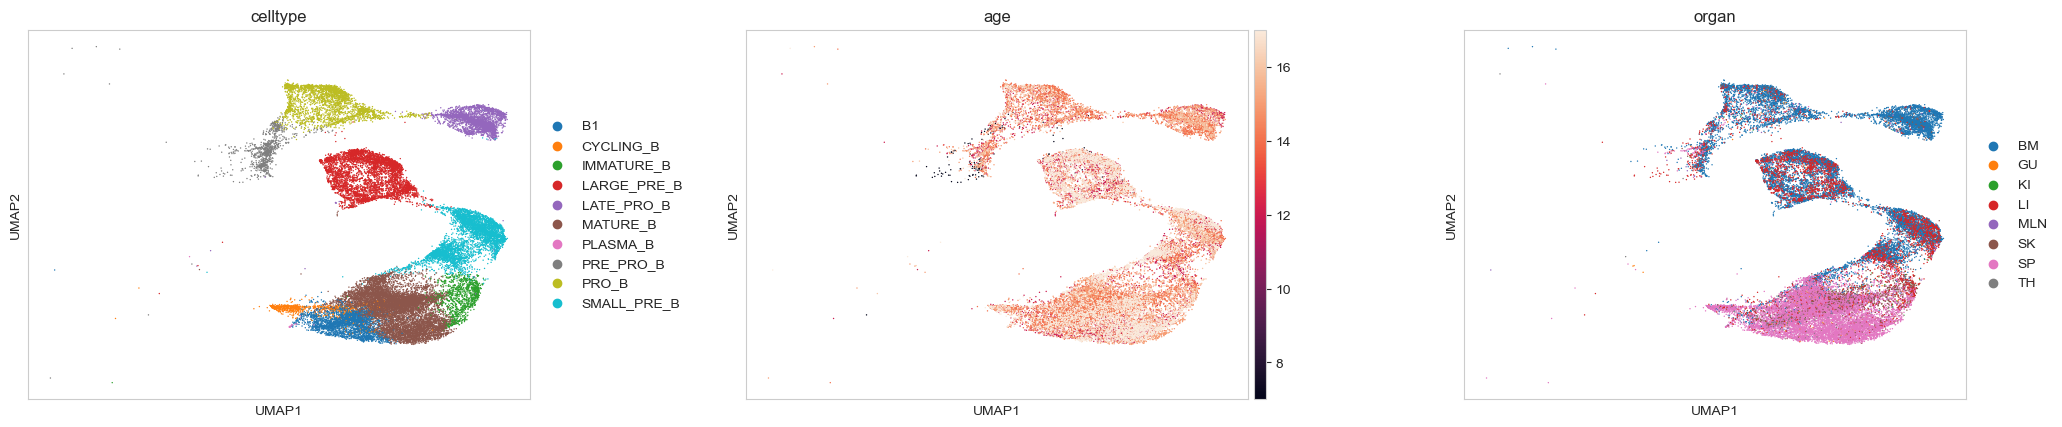

In [11]:
sc.pl.umap(adata, color = [ 'celltype','age','organ'],wspace = 0.3, ncols = 3)

In [14]:
# 计算q-tech得分

import os, glob, sys
import pandas as pd

# ---------- 参数 ----------
bcr_path = './data/panfetal_BCR/'
out_file = os.path.join(bcr_path, 'BCR_summary_all_pair.csv')
REQ_COLS = ['cdr1','cdr2','cdr3','fwr1','fwr2','fwr3','fwr4']

# ---------- 函数 ----------
def read_one_sample(sample_dir):
    """
    读一个目录下的 all_contig_annotations.csv
    不过滤低质量链；保留所有 contig + 质量标志，用于后续每细胞打分
    """
    csv_path = os.path.join(sample_dir, 'all_contig_annotations.csv')
    if not os.path.isfile(csv_path):
        return None
    sample_name = os.path.basename(sample_dir.rstrip('/'))
    df = pd.read_csv(csv_path)

    # 统一字段存在性（不同版本 cellranger 可能缺列）
    for col in ['productive','is_cell','high_confidence','full_length','umis','reads']:
        if col not in df.columns:
            df[col] = np.nan

    # 标记 CDR/FWR 是否缺失（缺失越多，可信度越低）
    for c in REQ_COLS:
        if c not in df.columns:
            df[c] = np.nan
    df['cdr_fwr_missing'] = df[REQ_COLS].isna().any(axis=1)

    # 拼全长序列（缺失区段会变成 NaN，后面想用再 drop 或 fill）
    df['full_aa'] = (df['fwr1'].fillna('') + df['cdr1'].fillna('') +
                     df['fwr2'].fillna('') + df['cdr2'].fillna('') +
                     df['fwr3'].fillna('') + df['cdr3'].fillna('') +
                     df['fwr4'].fillna(''))

    # 加 sample 前缀
    df['cell_id'] = sample_name + '-' + df['barcode'].astype(str)

    # 只保留我们需要的列
    keep = [
        'cell_id','barcode','chain','v_gene','d_gene','j_gene','c_gene',
        'cdr3','full_aa','cdr_fwr_missing',
        'productive','is_cell','high_confidence','full_length','umis','reads'
    ]
    keep = [c for c in keep if c in df.columns]
    return df[keep].copy()

def _safe_bool(x):
    if pd.isna(x):
        return False
    if isinstance(x, bool):
        return x
    if isinstance(x, (int, float)):
        try:
            return bool(int(x))
        except Exception:
            return False
    s = str(x).strip().lower()
    return s in ['true', '1', 't', 'yes', 'y']

# ---------- support scaling (fit once globally, use everywhere) ----------
_SUPPORT_SCALER = {'p05': 0.0, 'p95': 1.0}
## 目的：UMI/reads 的绝对数值受测序深度、试剂批次影响，不能固定阈值（比如“>6 UMI”），于是用“全局 5%–95% 分位数”把 log1p(UMI) 映射到 0–1。
## 全局只 fit 一次：把所有样本的 contig 先 concat，再算分位数，保证不同样本可比。
def fit_support_scaler(df: pd.DataFrame):
    """
    用全体 contig 的 log1p(umis/reads) 做自适应缩放，避免固定 /6 或 /10 导致批次偏差。
    """
    if df is None or df.empty:
        return
    x = pd.to_numeric(df.get('umis'), errors='coerce')
    if x is None or x.isna().all():
        x = pd.to_numeric(df.get('reads'), errors='coerce')
    x = x.dropna()
    if len(x) == 0:
        return
    lx = np.log1p(x.astype(float))
    p05, p95 = np.nanpercentile(lx, [5, 95])
    if not np.isfinite(p05): p05 = 0.0
    if not np.isfinite(p95): p95 = p05 + 1.0
    if p95 <= p05: p95 = p05 + 1.0
    _SUPPORT_SCALER['p05'] = float(p05)
    _SUPPORT_SCALER['p95'] = float(p95)

def _support_log1p(row):
    x = row.get('umis')
    if pd.isna(x):
        x = row.get('reads')
    if pd.isna(x):
        return 0.0
    try:
        return float(np.log1p(float(x)))
    except Exception:
        return 0.0

def _support_scaled_from_log(lx: float) -> float:
    p05, p95 = _SUPPORT_SCALER['p05'], _SUPPORT_SCALER['p95']
    z = (lx - p05) / (p95 - p05)
    return float(max(0.0, min(1.0, z)))

# high_confidence  0.45   （Cell Ranger 给的装配/注释可信标志）
# is_cell          0.20   （barcode 被判定为细胞）
# productive       0.15   （无终止密码子、无移码）
# full_length      0.10   （V 起始到 C 终止完整）
# cdr_fwr_missing  0.05   （7 段序列完整）
# support (UMI)    0.05   （经全局缩放）
def contig_quality_score(row):
    """
    单条 contig 的技术可信度分 (0~1)，用于在一个细胞内挑 heavy/light。
    设计原则：
    - high_confidence 为主（装配/注释可靠性）
    - is_cell 为辅（barcode 层面可信度）
    - productive 作为“可用性”加分，但 nonproductive 不直接判死刑
    - full_length / cdr_fwr_missing 仅小幅加分（避免与 productive 重复计分）
    - 支持度(UMI/reads)小幅加分，且用全局分位数自适应缩放
    """
    hc = 1.0 if _safe_bool(row.get('high_confidence')) else 0.0
    ic = 1.0 if _safe_bool(row.get('is_cell')) else 0.0
    pr = 1.0 if _safe_bool(row.get('productive')) else 0.0
    fl = 1.0 if _safe_bool(row.get('full_length')) else 0.0
    ok = 1.0 if (not _safe_bool(row.get('cdr_fwr_missing'))) else 0.0

    lx = _support_log1p(row)
    sup = _support_scaled_from_log(lx)

    # 权重和 = 1.0，输出即 0~1
    q = (
        0.45 * hc +
        0.20 * ic +
        0.15 * pr +
        0.10 * fl +
        0.05 * ok +
        0.05 * sup
    )
    return float(max(0.0, min(1.0, q)))


def pick_one_chain(group):
    """
    一个细胞内同一 chain 可能有多个 contig：
    选 q_tech_contig 最高的；并列再比支持度（umis/reads）。
    """
    g = group.copy()
    g['_q'] = g.apply(contig_quality_score, axis=1)
    g['_lx'] = g.apply(_support_log1p, axis=1)
    g = g.sort_values(by=['_q', '_lx'], ascending=False, kind='mergesort')
    return g.iloc[0].drop(labels=['_q', '_lx'])

# paired_bcr：是否同时有 best-heavy + best-light
# q_tech_bcr：技术可信度（0–1）
# has_heavy / has_light：布尔
# n_IGH_contigs / n_IGKIGL_contigs：原始 contig 数
# n_prod_IGH / n_prod_IGKIGL：productive 的 contig 数
# penalty_multichain：对“多 productive 链”的连续惩罚系数
# – IGH 每多一条 productive，惩罚 0.55^(n-1)（IGH 更严）
# – IGK/IGL 每多一条，惩罚 0.75^(n-1)
# – 最终 penalty = pen_H * pen_L
# q_tech_bcr 的计算公式：
# q = penalty * (0.60pair_term + 0.35qual_term + 0.05*sup_term)
# pair_term：配对 1.0，单链 0.55，全无 0.0
# qual_term：best-heavy 与 best-light 的 q_contig 平均（或单侧）
# sup_term：支持度缩放后平均（或单侧）

def summarize_cell_bcr(cell_contigs):
    """
    每细胞汇总 q_tech_bcr (0~1)：
    - 以“是否有可信 heavy/light”作为主信号（但不配对不直接归零）
    - 代表 contig 的 q_tech_contig 作为主体
    - 多重 productive 链（尤其 >1 IGH）做连续惩罚（doublet/多克隆风险）
    """
    heavy_all = cell_contigs[cell_contigs['chain'] == 'IGH']
    light_all = cell_contigs[cell_contigs['chain'].isin(['IGK', 'IGL'])]

    heavy_best = pick_one_chain(heavy_all) if len(heavy_all) else None
    light_best = pick_one_chain(light_all) if len(light_all) else None

    has_heavy = heavy_best is not None
    has_light = light_best is not None
    paired = has_heavy and has_light

    def qcontig(r):
        return contig_quality_score(r) if r is not None else 0.0

    qH = qcontig(heavy_best)
    qL = qcontig(light_best)

    # 配对项：有 heavy+light 才满；单链也给部分分（避免早期/低捕获全归零）
    pair_term = 1.0 if paired else (0.55 if (has_heavy or has_light) else 0.0)

    # 代表 contig 质量：paired 取平均；否则取存在的那个
    qual_term = (qH + qL) / 2.0 if paired else max(qH, qL)

    # 支持度：paired 取两者平均；否则取存在的那个（同样分位数缩放）
    def sup_scaled(r):
        if r is None:
            return 0.0
        return _support_scaled_from_log(_support_log1p(r))

    sup_term = (sup_scaled(heavy_best) + sup_scaled(light_best)) / 2.0 if paired else max(sup_scaled(heavy_best), sup_scaled(light_best))

    # 多重 productive 链计数（用 _safe_bool，避免 True/False 以外的类型漏算）
    def count_productive(df):
        if df is None or len(df) == 0 or 'productive' not in df.columns:
            return 0
        return int(df['productive'].apply(_safe_bool).sum())

    n_prod_heavy = count_productive(heavy_all)
    n_prod_light = count_productive(light_all)

    # 连续惩罚：>1 的每增加一条按比例衰减（IGH 更严格）
    # 例：IGH 2条→0.55，3条→0.30；light 2条→0.75，3条→0.56
    pen_H = 1.0 if n_prod_heavy <= 1 else (0.55 ** (n_prod_heavy - 1))
    pen_L = 1.0 if n_prod_light <= 1 else (0.75 ** (n_prod_light - 1))
    penalty = float(pen_H * pen_L)

    # 最终 q_tech：配对为主，质量其次，支持度最小
    q = penalty * (0.60 * pair_term + 0.35 * qual_term + 0.05 * sup_term)
    q = float(max(0.0, min(1.0, q)))

    out = {
        'paired_bcr': paired,
        'q_tech_bcr': q,          # 改名：这是技术可信度
        'has_heavy': has_heavy,
        'has_light': has_light,
        'n_IGH_contigs': int(len(heavy_all)),
        'n_IGKIGL_contigs': int(len(light_all)),
        'n_prod_IGH': int(n_prod_heavy),
        'n_prod_IGKIGL': int(n_prod_light),
        'penalty_multichain': penalty
    }
    return out, heavy_best, light_best


# ---------- 主流程（在 concat 后先 fit scaler） ----------
all_dfs = []
for subdir in glob.glob(os.path.join(bcr_path, '*/')):
    tmp = read_one_sample(subdir)
    if tmp is not None:
        all_dfs.append(tmp)

if not all_dfs:
    print('No all_contig_annotations.csv found!')
    sys.exit(1)

big = pd.concat(all_dfs, ignore_index=True)
fit_support_scaler(big)  # 新增：先拟合支持度缩放

rows = []
for cell_id, g in big.groupby('cell_id'):
    meta, heavy_best, light_best = summarize_cell_bcr(g)

    row = {'cell_id': cell_id, **meta}

    # 填 best heavy/light 序列与注释（即使低质也保留；没有则空）
    def put(prefix, r):
        """prefix 只能是 'Heavy' 或 'Light'"""
        if r is None:                       # 缺失链
            if prefix == 'Heavy':
                row.update({
                    'Heavy': '',
                    'cdrh3': '',
                    'ighv': '',
                    'ighj': '',
                    'ighc': '',
                    'cdr_fwr_missing_H': True
                })
            else:                           # Light
                row.update({
                    'Light': '',
                    'cdrl3': '',
                    'iglv': '',
                    'iglj': '',
                    'iglc': '',
                    'cdr_fwr_missing_L': True
                })
            return

        # 有链
        if prefix == 'Heavy':
            row['Heavy'] = r.get('full_aa', '')
            row['cdrh3'] = r.get('cdr3', '')
            row['ighv'] = r.get('v_gene', '')
            row['ighj'] = r.get('j_gene', '')
            row['ighc'] = r.get('c_gene', '')
            row['cdr_fwr_missing_H'] = bool(r.get('cdr_fwr_missing', True))
        else:                               # Light
            row['Light'] = r.get('full_aa', '')
            row['cdrl3'] = r.get('cdr3', '')
            row['iglv'] = r.get('v_gene', '')
            row['iglj'] = r.get('j_gene', '')
            row['iglc'] = r.get('c_gene', '')
            row['cdr_fwr_missing_L'] = bool(r.get('cdr_fwr_missing', True))

    put('Heavy', heavy_best)
    put('Light', light_best)

    rows.append(row)

cell_bcr = pd.DataFrame(rows)

# cols = [
#     'cell_id','q_bcr','paired_bcr','has_heavy','has_light',
#     'n_IGH_contigs','n_IGKIGL_contigs','n_prod_IGH','n_prod_IGKIGL',
#     'Heavy','Light','cdrh3','cdrl3','ighv','iglv','ighj','iglj','ighc','iglc',
#     'cdr_fwr_missing_H','cdr_fwr_missing_L'
# ]
# cols = [c for c in cols if c in cell_bcr.columns]
cols = cell_bcr.columns
cell_bcr[cols].to_csv(out_file, index=False)

In [20]:
cell_bcr['cdr_fwr_missing'] = cell_bcr['cdr_fwr_missing_H'] + cell_bcr['cdr_fwr_missing_L']

cell_bcr['cdr_fwr_missing'].value_counts()

cdr_fwr_missing
True     173161
False     24372
Name: count, dtype: int64

In [22]:
cell_bcr.columns

Index(['cell_id', 'paired_bcr', 'q_tech_bcr', 'has_heavy', 'has_light',
       'n_IGH_contigs', 'n_IGKIGL_contigs', 'n_prod_IGH', 'n_prod_IGKIGL',
       'penalty_multichain', 'Heavy', 'cdrh3', 'ighv', 'ighj', 'ighc',
       'cdr_fwr_missing_H', 'Light', 'cdrl3', 'iglv', 'iglj', 'iglc',
       'cdr_fwr_missing_L', 'cdr_fwr_missing'],
      dtype='object')

In [23]:
cell_bcr[ 'q_tech_bcr'].isna().value_counts()

q_tech_bcr
False    197533
Name: count, dtype: int64

In [24]:
## merge BCR 到 adata
# 1. 构造 cell_id ----------------------------------------------------------
# 1. 取出可变的 Series 副本
prefix = pd.Series(adata.obs_names.str.split('-').str[0], index=adata.obs_names)
suffix = adata.obs_names.str.split('-', n=1).str[1]      # 仍是 Series

# 只有 sample_id 非 NA 才做替换
mask = adata.obs['sample_id'].notna()
# 替换：sample_id 为字符串；若本身是 category 先转 str
repl = adata.obs['sample_id'].astype(str)
prefix[mask] = repl[mask]

# 拼回后半段
suffix = adata.obs_names.str.split('-', n=1).str[1]     # 不含第一个 "-"
adata.obs['cell_id'] = prefix + '-' + suffix

# 2. 与外部 df merge -------------------------------------------------------
infile = './data/panfetal_BCR/BCR_summary_all_pair.csv'

df = pd.read_csv(infile)
# df = df.drop(columns=['cdr_fwr_missing_H', 'cdr_fwr_missing_L'])
df['cell_id'] = df['cell_id'].str.rstrip('-1')

# 先把原始索引存下来，merge 完再恢复
orig_idx = adata.obs_names

# 以左边的 cell_id 做键，同时保留原索引
new_obs = (adata.obs
             .reset_index()                    # 把 index 变成普通列 'index'
             .merge(df, on='cell_id', how='left', suffixes=('', '_df'))
             .set_index('index')               # 恢复原来的行名
             .rename_axis(None))               # 去掉列名

# 确保顺序完全一致（防止 merge 重排行序）
new_obs = new_obs.loc[orig_idx]

# 写回
adata.obs = new_obs

print(adata.shape)
# adata = adata[adata.obs['q_bcr'].notna(),:].copy()
# print(adata.shape)
# adata.shape, df.shape, adata.obs['Heavy'].isna().sum(),adata.obs['Light'].isna().sum(),

# keep = adata.obs[['ighv', 'iglv', 'ighj', 'iglj','Heavy', 'Light', 'cdrh3', 'cdrl3',]].notna().all(axis=1)
# adata = adata[keep, :].copy()
# print(adata.shape)

(29818, 33538)


In [155]:
adata.obs['celltype'].value_counts()

celltype
MATURE_B       7462
LARGE_PRE_B    4171
SMALL_PRE_B    4025
B1             2379
IMMATURE_B      939
CYCLING_B       720
LATE_PRO_B      155
PRO_B           110
PRE_PRO_B        35
PLASMA_B         22
Name: count, dtype: int64

In [28]:
adata.obs['q_tech_bcr'].isna().value_counts()

q_tech_bcr
False    20018
True      9800
Name: count, dtype: int64

In [31]:
adata.obs['ighc'].value_counts()

ighc
IGHM     19623
IGHD       372
IGHG2        2
IGHG1        1
IGHA2        1
Name: count, dtype: int64

In [42]:
adata.obs['iglc'].value_counts()

iglc
IGKC     8858
IGLC2    3604
IGLC3    1612
IGLC1    1160
IGLC7      30
Name: count, dtype: int64

In [40]:
adata.obs['ighj'].value_counts()

ighj
IGHJ4    9198
IGHJ3    5452
IGHJ2    2536
IGHJ5    1319
IGHJ6    1299
IGHJ1     206
Name: count, dtype: int64

In [43]:
adata.obs['iglj'].value_counts()

iglj
IGLJ2    3250
IGKJ2    2616
IGKJ1    2276
IGKJ4    2053
IGLJ3    1982
IGKJ3    1250
IGLJ1    1144
IGKJ5     661
IGLJ7      29
IGLJ6      21
IGHJ1       1
Name: count, dtype: int64

In [41]:
adata.obs['ighv'].value_counts()

ighv
IGHV1-2         2157
IGHV3-33        1862
IGHV3-23        1188
IGHV6-1         1164
IGHV3-21         998
IGHV3-7          909
IGHV4-34         903
IGHV4-59         803
IGHV1-69D        707
IGHV1-8          681
IGHV5-51         661
IGHV3-15         646
IGHV3-30         624
IGHV4-39         606
IGHV3-11         504
IGHV2-5          494
IGHV1-3          450
IGHV1-18         400
IGHV4-30-4       393
IGHV3-43         390
IGHV3-48         373
IGHV3-53         363
IGHV2-26         304
IGHV1-46         223
IGHV2-70         193
IGHV1-69         189
IGHV5-10-1       185
IGHV3-13         182
IGHV4-4          171
IGHV4-38-2       170
IGHV3-74         168
IGHV3-66         157
IGHV3-73         135
IGHV3-64D        129
IGHV4-61         105
IGHV1-24          70
IGHV4-31          56
IGHV3-49          55
IGHV1-58          53
IGHV3-20          49
IGHV7-4-1         48
IGHV2-70D         29
IGHV3-72          26
IGHV3-64          12
IGHV4-28          11
IGHV1-69-2        10
IGHV1-45           7
IGHV4-30

In [34]:
adata.obs['mu_count'].value_counts()

mu_count
0.000000     17980
0.500000      1134
1.000000       452
1.500000       140
2.000000        82
5.000000        69
10.000000       20
4.500000        19
6.000000        13
3.000000        13
4.000000        10
0.333333         9
2.500000         8
12.500000        7
9.000000         6
8.000000         5
21.000000        5
9.500000         4
0.666667         3
3.500000         3
17.500000        3
12.000000        3
22.000000        3
10.500000        3
17.000000        2
20.000000        2
19.500000        2
14.500000        2
7.333333         1
11.500000        1
35.000000        1
13.333333        1
41.000000        1
25.000000        1
15.000000        1
13.000000        1
14.000000        1
3.250000         1
0.250000         1
7.000000         1
5.500000         1
18.000000        1
20.500000        1
11.000000        1
Name: count, dtype: int64

/var/folders/5m/ftv2kftx4glfclc0_df64vc80000gn/T/ipykernel_14297/1413880939.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('celltype')[time_col]


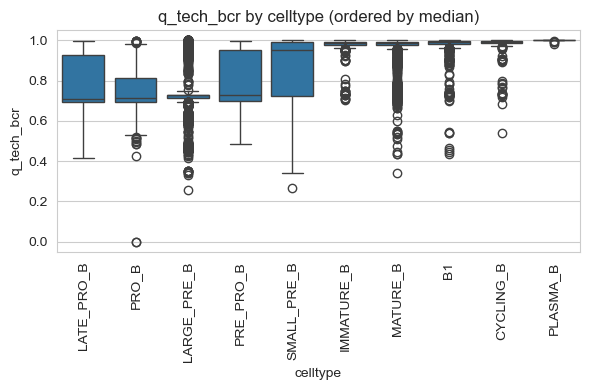

In [29]:
# adata_sub = adata[adata.obs['q_bcr'].notna(),:].copy()
# print(adata_sub.shape)

# boxplot_by_median(adata_sub, 'q_bcr')
boxplot_by_median(adata, 'q_tech_bcr')

In [44]:
adata

AnnData object with n_obs × n_vars = 29818 × 33538
    obs: 'n_counts', 'n_genes', 'file', 'mito', 'doublet_scores', 'predicted_doublets', 'old_annotation_uniform', 'organ', 'Sort_id', 'age', 'method', 'donor', 'sex', 'Sample', 'scvi_clusters', 'is_maternal_contaminant', 'anno_lvl_2_final_clean', 'celltype', 'filter_rna', 'has_contig', 'filter_contig_quality', 'filter_contig_VDJ', 'filter_contig_VJ', 'contig_QC_pass', 'filter_contig', 'clone_id', 'clone_id_by_size', 'sample_id', 'locus_VDJ', 'locus_VJ', 'productive_VDJ', 'productive_VJ', 'v_call_genotyped_VDJ', 'v_call_genotyped_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'duplicate_count_VDJ', 'duplicate_count_VJ', 'duplicate_count_VDJ_1', 'duplicate_count_VJ_1', 'duplicate_count_VDJ_2', 'duplicate_count_VDJ_3', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_status', 'locus_status_summary', 'productive', 'productive_summary', 'isotype', 'isotype_summary', 'vdj_status', 'vdj_status_summary', 'constant_status_s

In [90]:
list(adata.obs['celltype'].unique())

['MATURE_B',
 'B1',
 'LARGE_PRE_B',
 'CYCLING_B',
 'IMMATURE_B',
 'SMALL_PRE_B',
 'PLASMA_B',
 'LATE_PRO_B',
 'PRE_PRO_B',
 'DOUBLET_ERY_B',
 'PRO_B']

In [48]:
adata

AnnData object with n_obs × n_vars = 29818 × 33538
    obs: 'n_counts', 'n_genes', 'file', 'mito', 'doublet_scores', 'predicted_doublets', 'old_annotation_uniform', 'organ', 'Sort_id', 'age', 'method', 'donor', 'sex', 'Sample', 'scvi_clusters', 'is_maternal_contaminant', 'anno_lvl_2_final_clean', 'celltype', 'filter_rna', 'has_contig', 'filter_contig_quality', 'filter_contig_VDJ', 'filter_contig_VJ', 'contig_QC_pass', 'filter_contig', 'clone_id', 'clone_id_by_size', 'sample_id', 'locus_VDJ', 'locus_VJ', 'productive_VDJ', 'productive_VJ', 'v_call_genotyped_VDJ', 'v_call_genotyped_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'duplicate_count_VDJ', 'duplicate_count_VJ', 'duplicate_count_VDJ_1', 'duplicate_count_VJ_1', 'duplicate_count_VDJ_2', 'duplicate_count_VDJ_3', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_status', 'locus_status_summary', 'productive', 'productive_summary', 'isotype', 'isotype_summary', 'vdj_status', 'vdj_status_summary', 'constant_status_s

(array([1.9828e+04, 1.1200e+02, 4.0000e+01, 1.4000e+01, 1.1000e+01,
        9.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([0.        , 0.01188406, 0.02376812, 0.03565217, 0.04753623,
        0.05942029, 0.07130435, 0.08318841, 0.09507246, 0.10695652,
        0.11884058]),
 <BarContainer object of 10 artists>)

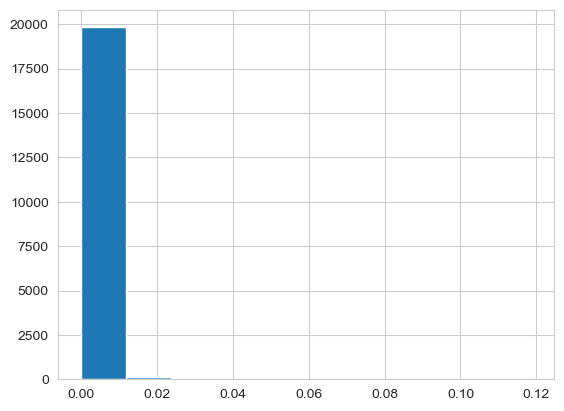

In [49]:
plt.hist(adata.obs['mu_freq'])

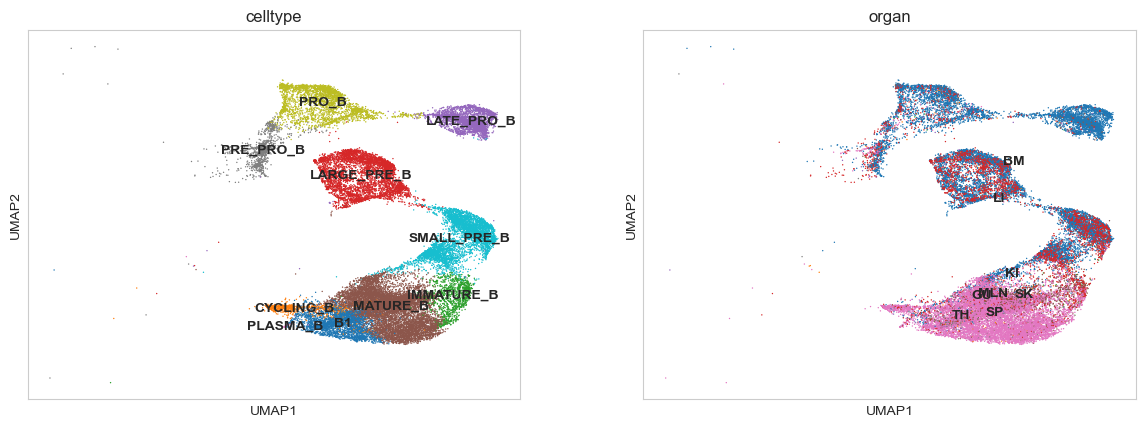

In [50]:
sc.pl.umap(adata, color = [ 'celltype','organ'],legend_loc='on data',)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(<Figure size 1500x300 with 5 Axes>,
 {0: <Axes: title={'center': 'Component 0'}>,
  1: <Axes: title={'center': 'Component 1'}>,
  2: <Axes: title={'center': 'Component 2'}>,
  3: <Axes: title={'center': 'Component 3'}>,
  4: <Axes: title={'center': 'Component 4'}>})

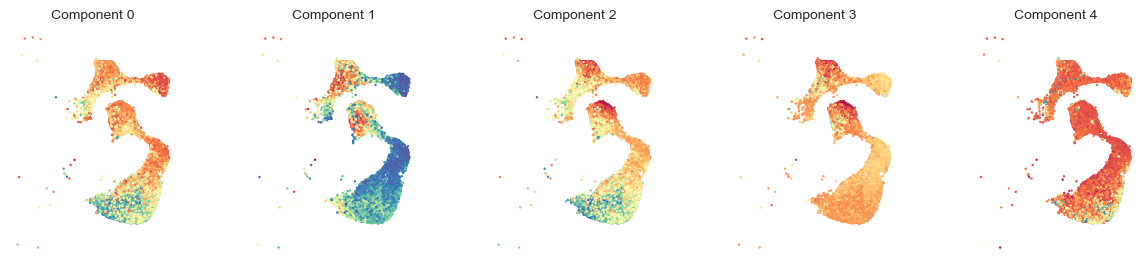

In [51]:
# 加载所需的python包
import palantir
# Plotting and miscellaneous imports
import os
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
# https://github.com/dpeerlab/Palantir/blob/master/notebooks/Palantir_sample_notebook.ipynb

# 运行Palantir
# PRE_PRO_B 是最合理的选择——它位于最上游，尚未表达CD19、CD20等成熟标记，
# 后续依次经过PRO_B → PRE_B → IMMATURE_B → MATURE_B，最终可走向PLASMA_B或B1等亚群

# Run diffusion maps
sc.pp.pca(adata)
dm_res = palantir.utils.run_diffusion_maps(adata, n_components=5, )
ms_data = palantir.utils.determine_multiscale_space(adata)
palantir.plot.plot_diffusion_components(adata,  )


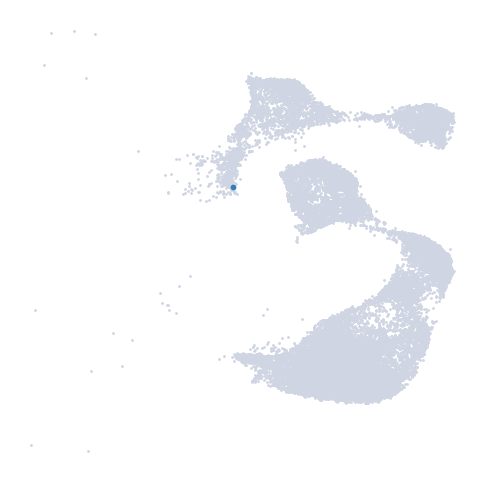

In [52]:
start_cell = np.random.choice(
    adata.obs_names[(adata.obs['celltype'] == 'PRE_PRO_B') & (adata.obs['mu_freq'] == 0)],
    size=1,
    replace=False
)[0]          # 取出唯一的 str
palantir.plot.highlight_cells_on_umap(adata, [start_cell])
plt.show()


In [53]:
pr_res = palantir.core.run_palantir(ms_data, start_cell, num_waypoints=500,terminal_states=None)


Sampling and flocking waypoints...
Time for determining waypoints: 0.013756267229715983 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.3297889312108358 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9993
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


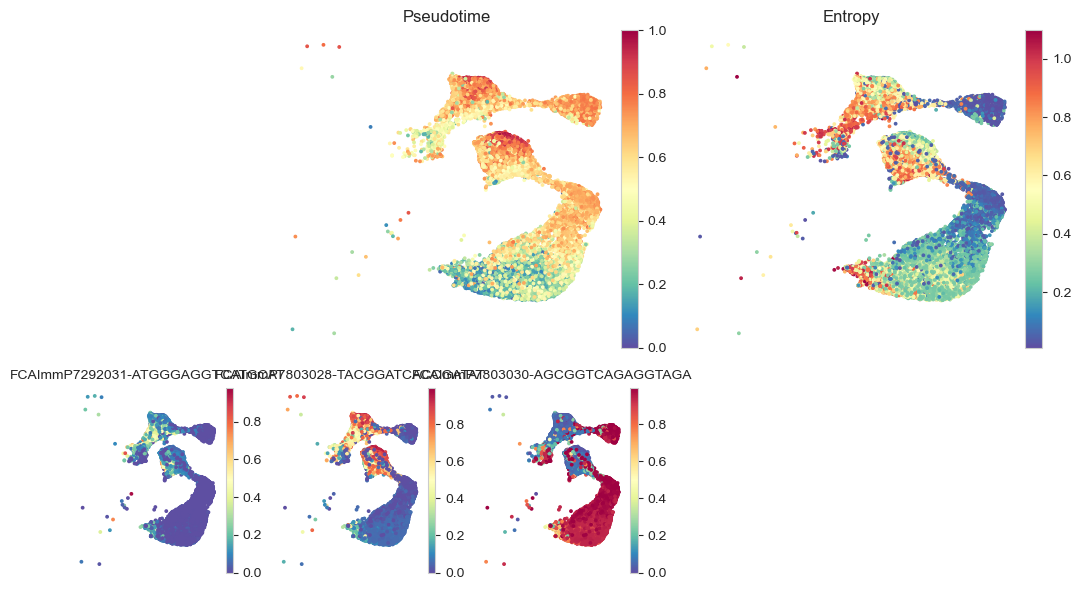

In [54]:
palantir.plot.plot_palantir_results(adata, pr_res,s=3)
plt.show()

In [55]:
# sc.pp.neighbors(adata, use_rep='X_scvi', n_neighbors=50)
# sc.tl.umap(adata)
# palantir.plot.plot_palantir_results(adata, pr_res,s=3)
# plt.show()

/var/folders/5m/ftv2kftx4glfclc0_df64vc80000gn/T/ipykernel_43668/1413880939.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('celltype')[time_col]


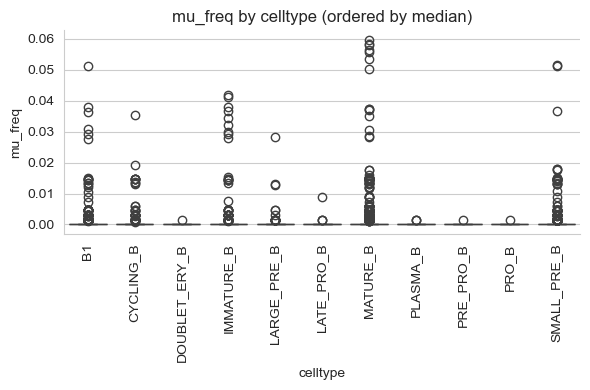

In [130]:
boxplot_by_median(adata,'mu_freq')

/var/folders/5m/ftv2kftx4glfclc0_df64vc80000gn/T/ipykernel_14297/1413880939.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('celltype')[time_col]


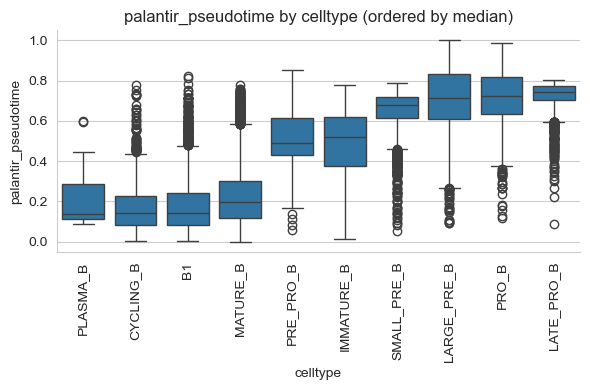

In [56]:
# 取出 Series（index 与 adata.obs_names 一致）
palantir_pseudotime = pr_res.pseudotime

# 如果想直接写回 adata.obs：
adata.obs['palantir_pseudotime'] = palantir_pseudotime

boxplot_by_median(adata, 'palantir_pseudotime')

In [58]:
# adata_2.shape,adata.shape

((13109, 33538), (29818, 33538))

In [60]:
adata.obs

,n_counts,n_genes,file,mito,doublet_scores,predicted_doublets,old_annotation_uniform,organ,Sort_id,age,...,ighj,ighc,cdr_fwr_missing_H,Light,cdrl3,iglv,iglj,iglc,cdr_fwr_missing_L,palantir_pseudotime
index,,,,,,,,,,,,,,,,,,,,,
Human_colon_16S8159187-AGCTCTCAGTGTACTC,12236.0,2627,Human_colon_16S8159187,0.032772,0.293388,True,nan,GU,CD45P_CD45N,15,...,IGHJ3,IGHM,False,DIVMTQSPDSLAVSLGERATINCKSSQSVLYSSNNKNYLAWYQQKP...,CQQYYSTPYTF,IGKV4-1,IGKJ2,IGKC,False,0.072684
Human_colon_16S8159187-TTAGGCATCAAGAAGT,11355.0,2709,Human_colon_16S8159187,0.035315,0.136000,False,nan,GU,CD45P_CD45N,15,...,IGHJ4,IGHM,False,SYELTQPPSVSVSPGQTARITCSGDALPKKYAYWYQQKSGQAPVLV...,CYSTDSSGNHSVF,IGLV3-10,IGLJ2,IGLC2,False,0.108614
Human_colon_16S8159187-AGAATAGAGTGTGAAT,8394.0,2161,Human_colon_16S8159187,0.024184,0.195231,False,nan,GU,CD45P_CD45N,15,...,IGHJ3,IGHM,False,SYELTQPPSVSVSPGQTASITCSGDKLGDKYACWYQQKPGQSPVLV...,CQAWDSSTAVVF,IGLV3-1,IGLJ2,IGLC2,False,0.136110
Human_colon_16S8159187-GGATTACAGAGAGCTC,7740.0,2316,Human_colon_16S8159187,0.024419,0.112676,False,nan,GU,CD45P_CD45N,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.787394
Human_colon_16S8159187-TTCTACACATACAGCT,6661.0,1625,Human_colon_16S8159187,0.014112,0.109792,False,nan,GU,CD45P_CD45N,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.222508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FCAImmP7803020-CGATCGGGTAGAGCTG,2074.0,693,FCAImmP7803020,0.030858,0.030568,False,nan,SP,CD45P,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.709220
FCAImmP7803020-AGACGTTAGAGGTTAT,2064.0,890,FCAImmP7803020,0.021318,0.023443,False,B CELL,SP,CD45P,15,...,IGHJ3,IGHM,False,DIVMTQSPDSLAVSLGERATINCKSSQSVLYSSNNKNYLAWYQQKP...,CQQYYSTPGSWWTF,IGKV4-1,IGKJ1,IGKC,False,0.495572
FCAImmP7803020-GTGTTAGCACCGGAAA,2048.0,737,FCAImmP7803020,0.016113,0.028409,False,nan,SP,CD45P,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.710822


In [62]:
fdir_file = './data/'

def obj_cols_to_str(obs: pd.DataFrame, na_str: str = "") -> pd.DataFrame:
    """
    自动把 obs 中所有 object 列里的非字符串元素转成字符串。
    返回修改后的 DataFrame（原位修改，也可接 copy() 用副本）。
    """
    obj_cols = obs.select_dtypes(include=["object"]).columns
    for col in obj_cols:
        # 把 None / nan 换成空字符串，其余直接 str()
        obs[col] = obs[col].apply(
            lambda x: na_str if pd.isna(x) or x is None else str(x)
        )
    return obs


# 用法
adata.obs = obj_cols_to_str(adata.obs)          # 原地修改

# adata.write(fdir_file + 'Bcells_merged_BCR_palantir_pseudotime.h5ad') # data_v1:13109 cells
adata.write(fdir_file + 'Bcells_merged_BCR_palantir_pseudotime_v2.h5ad') # data_v2:29818 cells


In [64]:
adata.obs

,n_counts,n_genes,file,mito,doublet_scores,predicted_doublets,old_annotation_uniform,organ,Sort_id,age,...,ighj,ighc,cdr_fwr_missing_H,Light,cdrl3,iglv,iglj,iglc,cdr_fwr_missing_L,palantir_pseudotime
index,,,,,,,,,,,,,,,,,,,,,
Human_colon_16S8159187-AGCTCTCAGTGTACTC,12236.0,2627,Human_colon_16S8159187,0.032772,0.293388,True,nan,GU,CD45P_CD45N,15,...,IGHJ3,IGHM,False,DIVMTQSPDSLAVSLGERATINCKSSQSVLYSSNNKNYLAWYQQKP...,CQQYYSTPYTF,IGKV4-1,IGKJ2,IGKC,False,0.072684
Human_colon_16S8159187-TTAGGCATCAAGAAGT,11355.0,2709,Human_colon_16S8159187,0.035315,0.136000,False,nan,GU,CD45P_CD45N,15,...,IGHJ4,IGHM,False,SYELTQPPSVSVSPGQTARITCSGDALPKKYAYWYQQKSGQAPVLV...,CYSTDSSGNHSVF,IGLV3-10,IGLJ2,IGLC2,False,0.108614
Human_colon_16S8159187-AGAATAGAGTGTGAAT,8394.0,2161,Human_colon_16S8159187,0.024184,0.195231,False,nan,GU,CD45P_CD45N,15,...,IGHJ3,IGHM,False,SYELTQPPSVSVSPGQTASITCSGDKLGDKYACWYQQKPGQSPVLV...,CQAWDSSTAVVF,IGLV3-1,IGLJ2,IGLC2,False,0.136110
Human_colon_16S8159187-GGATTACAGAGAGCTC,7740.0,2316,Human_colon_16S8159187,0.024419,0.112676,False,nan,GU,CD45P_CD45N,15,...,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,,0.787394
Human_colon_16S8159187-TTCTACACATACAGCT,6661.0,1625,Human_colon_16S8159187,0.014112,0.109792,False,nan,GU,CD45P_CD45N,15,...,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,,0.222508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FCAImmP7803020-CGATCGGGTAGAGCTG,2074.0,693,FCAImmP7803020,0.030858,0.030568,False,nan,SP,CD45P,15,...,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,,0.709220
FCAImmP7803020-AGACGTTAGAGGTTAT,2064.0,890,FCAImmP7803020,0.021318,0.023443,False,B CELL,SP,CD45P,15,...,IGHJ3,IGHM,False,DIVMTQSPDSLAVSLGERATINCKSSQSVLYSSNNKNYLAWYQQKP...,CQQYYSTPGSWWTF,IGKV4-1,IGKJ1,IGKC,False,0.495572
FCAImmP7803020-GTGTTAGCACCGGAAA,2048.0,737,FCAImmP7803020,0.016113,0.028409,False,nan,SP,CD45P,15,...,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,,0.710822


In [66]:
adata.obs['q_tech_bcr'].isna().sum()

np.int64(9800)

In [123]:
adata.obs['clone_id'].value_counts()

clone_id
228_7_3_23_3_5      4
183_8_25_244_4_9    3
38_9_27_204_1_1     3
183_8_13_284_4_3    2
105_8_36_230_5_8    2
                   ..
95_11_6_85_1_2      1
95_11_7_268_3_3     1
95_11_8_125_3_8     1
95_11_9_302_9_1     1
304_14_1_230_4_7    1
Name: count, Length: 13021, dtype: int64

In [124]:
adata.obs['organ'].value_counts()

organ
SP     8598
BM     1816
SK     1049
LI      968
MLN     439
GU      165
KI       65
TH        9
Name: count, dtype: int64

In [125]:
# Bone marrow, Kidney, Liver, Mesenteric lymph node, Skin of body, Spleen, Thymus, Yolk sac
adata.obs['cell_id'].value_counts()

cell_id
Human_colon_16S8157868-AGCTCTCAGTGTACTC    1
WSSS_F_Imm10014573-ACACCCTCATCGATGT        1
WSSS_F_Imm10014573-GCAATCACAGATAATG        1
WSSS_F_Imm10014573-CGCTGGAAGGACTGGT        1
WSSS_F_Imm10014573-TAAACCGCAAGAAAGG        1
                                          ..
WSSS_F_Imm10014564-GTCACGGGTCGAGTTT        1
WSSS_F_Imm10014564-GTTCTCGAGTACGACG        1
WSSS_F_Imm10014564-CCTAGCTGTTATGTGC        1
WSSS_F_Imm10014564-GCGGGTTCACTTGGAT        1
WSSS_F_Imm10014575-CGATGTAGTCTGCGGT        1
Name: count, Length: 13109, dtype: int64